In [1]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import os
import time
from IPython.display import clear_output
import pathlib
import matplotlib.pyplot as plt

In [30]:
HEADERS = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
VALID_SEASONS = ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
BASE_URL = 'https://www.transfermarkt.de'


### Get all teams

In [ ]:
# Get all teams participating in DFB Pokal since 2014-15 season


for season in VALID_SEASONS:
    teams = []
    teams_links = []
    link = BASE_URL + f'dfb-pokal/startseite/pokalwettbewerb/DFB?saison_id={season}'
    response = requests.get(link, headers=HEADERS)
    soup = BeautifulSoup(response.content, 'html.parser')


    # Find all 'tr' tags with the class 'begegnungZeile'
    rows = soup.find_all('tr', class_='begegnungZeile')

    for row in rows:
        home_team = row.find('td', class_='verein-heim')
        away_team = row.find('td', class_='verein-gast')
        if home_team and away_team:
            home_team_title = home_team.find('a')['title']
            home_team_link = home_team.find('a')['href']
            away_team_title = away_team.find_all('a')[1]['title']
            away_team_link = away_team.find_all('a')[1]['href']
            teams_links.append(home_team_link[:-4])
            teams_links.append(away_team_link[:-4])
            teams.append(home_team_title)
            teams.append(away_team_title)

    if len(teams_links) == 0:
        print(f"No teams found for {season} season")
        continue
    else:
        print(f"Found {len(set(teams_links))} teams in {season} season")


    df = pd.DataFrame({'team': teams, 'link': teams_links, 'season': season})
    # Remove duplicates
    df = df.drop_duplicates(subset=['team', 'link'])
    # Reset index
    df = df.reset_index(drop=True)
    # Save to CSV
    df.to_csv(f'datasets/teams/{season}.csv', index=False)



Found 64 teams in 2014 season
Found 64 teams in 2015 season
Found 64 teams in 2016 season
Found 64 teams in 2017 season
Found 64 teams in 2018 season
Found 64 teams in 2019 season
Found 64 teams in 2020 season
Found 64 teams in 2021 season
Found 64 teams in 2022 season
Found 64 teams in 2023 season
Found 64 teams in 2024 season


In [13]:
# Path to the folder containing the CSV files
folder_path = 'datasets/teams/'

# List to store dataframes
dataframes = []

# Iterate through all files in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        # Read the CSV file and append it to the list
        dataframes.append(pd.read_csv(file_path))

# Combine all dataframes into a single dataframe
combined_df = pd.concat(dataframes, ignore_index=False)

# remove duplicates
combined_df = combined_df.drop_duplicates(subset=['team'])
# Reset index
combined_df = combined_df.reset_index(drop=True)

# Display the combined dataframe
teams_df = combined_df.drop(columns=['season'])

teams_df.to_csv('datasets/teams/teams.csv', index=False)

In [5]:
# Get additional data for each team

teams_df = pd.read_csv('datasets/teams/teams.csv')
new_data = pd.DataFrame(columns=['link', 'stadium_name', 'total_capacity', 'lawn_heating', 'field_length', 'field_width'])

for index, row in teams_df.iterrows():
    print(f"{index}",end=' ')
    additional_data = {
        'link': '',
        'stadium_name': '',
        'total_capacity': '',
        'lawn_heating': '',
        'field_length': '',
        'field_width': ''
    }

    team_link = row['link']
    final_link = BASE_URL + team_link.replace('spielplan','stadion') + '2014'
    print(final_link)
    response = requests.get(final_link, headers=HEADERS)
    soup = BeautifulSoup(response.content, 'html.parser')
    table = soup.find('table', class_='profilheader')

    # Extract the data from the table
    additional_data['link'] = team_link
    additional_data['stadium_name'] = table.find('th', string='Stadionname:').find_next('td').text.strip()
    try:
        additional_data['total_capacity'] = table.find('th', string='Gesamtkapazität:').find_next('td').text.strip()
    except AttributeError:
        additional_data['total_capacity'] = ''
    try:
        additional_data['lawn_heating'] = table.find('th', string='Rasenheizung:').find_next('td').text.strip()
    except AttributeError:
        additional_data['lawn_heating'] = ''
    
    try:
        playing_surface = table.find('th', string='Spielfeldgröße:').find_next('td').text.strip()
        additional_data['field_length'] = playing_surface.split('x')[0].strip().split('m')[0]
        additional_data['field_width'] = playing_surface.split('x')[1].strip().split('m')[0]
    except AttributeError:
        additional_data['field_length'] = ''
        additional_data['field_width'] = ''

    # Append the data to the new dataframe
    new_data = pd.concat([new_data, pd.DataFrame([additional_data])], ignore_index=True)



0 https://www.transfermarkt.de/borussia-dortmund/stadion/verein/16/saison_id/2014
1 https://www.transfermarkt.de/vfl-wolfsburg/stadion/verein/82/saison_id/2014
2 https://www.transfermarkt.de/fc-bayern-munchen/stadion/verein/27/saison_id/2014
3 https://www.transfermarkt.de/arminia-bielefeld/stadion/verein/10/saison_id/2014
4 https://www.transfermarkt.de/sc-freiburg/stadion/verein/60/saison_id/2014
5 https://www.transfermarkt.de/tsg-1899-hoffenheim/stadion/verein/533/saison_id/2014
6 https://www.transfermarkt.de/borussia-monchengladbach/stadion/verein/18/saison_id/2014
7 https://www.transfermarkt.de/bayer-04-leverkusen/stadion/verein/15/saison_id/2014
8 https://www.transfermarkt.de/vfr-aalen/stadion/verein/83/saison_id/2014
9 https://www.transfermarkt.de/1-fc-kaiserslautern/stadion/verein/2/saison_id/2014
10 https://www.transfermarkt.de/sg-dynamo-dresden/stadion/verein/129/saison_id/2014
11 https://www.transfermarkt.de/1-fc-koln/stadion/verein/3/saison_id/2014
12 https://www.transfermark

In [7]:
# Merge the new data with teams_df on the 'link' column
updated_teams_df = teams_df.merge(new_data, on='link', how='left')

# Display the updated dataframe
updated_teams_df

# Save the updated dataframe to a CSV file
updated_teams_df.to_csv('datasets/teams/teams.csv', index=False)

### Get all players

In [ ]:
positions = {
    'Torwart': 'GK',
    'Innenverteidiger': 'CB',
    'Abwehr': 'CB',
    'Mittelfeld': 'Midfielder',
    'Linker Verteidiger' : 'LB',
    'Rechter Verteidiger' : 'RB',
    'Defensives Mittelfeld' : 'CDM',
    'Zentrales Mittelfeld' : 'CM',
    'Linkes Mittelfeld' : 'LM',
    'Rechtes Mittelfeld' : 'RM',
    'Offensives Mittelfeld' : 'CAM',
    'Rechtsaußen': 'RW',
    'Linksaußen': 'LW',
    'Mittelstürmer': 'ST',
    'Sturm': 'ST',
    'Hängende Spitze': 'Second Striker',
    'Libero': 'Sweeper',
}

# List of all scraped teams
scraped_teams = [os.path.splitext(f)[0] for f in os.listdir('datasets/players') if f.endswith('.csv')]
scraped_teams.append('SV Drochtersen/Assel')
scraped_teams.append('1.FC Germania Egestorf/Langreder')

teams_df = pd.read_csv('datasets/teams/teams.csv')

for index, row in teams_df.iterrows():
    data = []
    selected_team = row
    if selected_team['team'] in scraped_teams:
        continue
    print(f"Scraping {selected_team['team']}:")
    for season in VALID_SEASONS:
        print(season)
        if season != '2024':
            final_link = BASE_URL + selected_team['link'].replace('spielplan','kader').replace('saison_id/','plus/0/galerie/0?saison_id=') + season
        else: 
            final_link = BASE_URL + selected_team['link'].replace('spielplan','startseite').replace('saison_id/','')
        while True:
                response = requests.get(final_link, headers=HEADERS)
                if response.content and b'Service Unavailable' not in response.content and response.status_code == 200:
                    break
                print("Empty or error response, retrying in 5 seconds...")
                time.sleep(5)
            
        soup = BeautifulSoup(response.content, 'html.parser')
        table = soup.find('table', class_='items')

        # Extract the data from the table
        try:
            rows = table.find_all('tr')[1::3]  # Skip the header row
        except:
            print(f"No data found for {selected_team['team']} in {season} season")
            continue
        for row in rows:
            cols = row.find_all('td')
            if len(cols) > 0:
                try:
                    if season != '2024':
                        player_data = {
                            'name': cols[1].text.strip().split("\n")[0].strip(),
                            'position': positions[cols[1].text.strip().split("\n")[-1].strip()],
                            'age': cols[5].text.strip(),
                            'value': cols[8].text.strip(),
                            'team': selected_team['team'],
                            'season': season,
                        }
                    else:
                        player_data = {
                            'name': cols[1].text.strip().split("\n")[0].strip(),
                            'position': positions[cols[1].text.strip().split("\n")[-1].strip()],
                            'age': cols[5].text.split(' ')[1][1:-1],
                            'value': cols[7].text.strip(),
                            'team': selected_team['team'],
                            'season': season,
                        }
                    data.append(player_data)
                except KeyError:
                    continue

    df = pd.DataFrame(data)
    # Remove duplicates
    df = df.drop_duplicates(subset=['name', 'season'])
    # Reset index
    df = df.reset_index(drop=True)
    # Save to CSV
    if '/' in selected_team['team']:
        df.to_csv(f'datasets/players/{selected_team['team'].replace('/','-')}.csv', index=False)
    else:
        df.to_csv(f'datasets/players/{selected_team['team']}.csv', index=False)

    print(f"Saved {selected_team['team']} data to CSV")
    print(f"Sleeping for 1 minutes to avoid overloading the server...")
    time.sleep(60)
    clear_output(wait=True)

In [ ]:
# Path to the folder containing the CSV files
folder_path = 'datasets/players/'

# List to store dataframes
dataframes = []

# Iterate through all files in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        # Read the CSV file and append it to the list
        dataframes.append(pd.read_csv(file_path))

# Combine all dataframes into a single dataframe
combined_df = pd.concat(dataframes, ignore_index=False)

# Reset index
combined_df = combined_df.reset_index(drop=True)

combined_df.to_csv('datasets/players/players.csv', index=False)

combined_df

### Team Schedules

In [21]:
# team schedule
teams_df = pd.read_csv('datasets/teams/teams.csv')
scraped_teams = [os.path.splitext(f)[0] for f in os.listdir('datasets/schedules') if f.endswith('.csv')]
for index, row in teams_df.iterrows():
    selected_team = row
    if selected_team['team'] in scraped_teams:
        continue
    print(f"Scraping {selected_team['team']}:")

    data = []
    for season in VALID_SEASONS:
        final_link = BASE_URL + selected_team['link'] + season
        print(season, final_link)


        # Fetch the webpage using requests
        response = requests.get(final_link, headers=HEADERS)

        # Parse the page source with BeautifulSoup
        soup = BeautifulSoup(response.text, 'html.parser')
        if season == '2024':
            competitions = soup.find_all('div', class_='box')[3:-2]
        else:
            competitions = soup.find_all('div', class_='box')[2:-2]
        for competition in competitions:
            # Find the title of the competition
            title = competition.find('a').text.strip()
            table = competition.find('table')
            if table:
                rows = table.find_all('tr')[1:]  # Skip the header row
                for row in rows:
                    cols = row.find_all('td')
                    if len(cols) > 0:
                        try:
                            date = cols[1].text.split('. ')[1].strip()
                            time = cols[2].text.strip()
                        except:
                            date = ''
                            time = ''
                        host = cols[3].text.strip()
                        if host == 'H':
                            home_team = selected_team['team']
                            away_team = cols[6].text.strip().split('(')[0].strip()
                            home_rank = cols[4].text.strip()[1:].split('.')[0]
                            try:
                                away_rank = cols[6].text.strip().split('(')[1].split('.')[0].strip()
                            except:
                                away_rank = ''
                        else:
                            home_team = cols[6].text.strip().split('(')[0].strip()
                            away_team = selected_team['team']
                            try:
                                home_rank = cols[6].text.strip().split('(')[1].split('.')[0].strip()
                            except:
                                home_rank = ''
                            away_rank = cols[4].text.strip()[1:].split('.')[0]
                        
                        participants = cols[8].text.strip()
                        result = cols[9].text.strip()
                        try:
                            home_score = result.split(':')[0].strip()
                            away_score = result.split(':')[1].split(' ')[0].strip()
                        except:
                            home_score = ''
                            away_score = ''

                        match_link = cols[9].find('a')['href']
                        match_data = {
                            'date': date,
                            'time': time,
                            'home_team': home_team,
                            'away_team': away_team,
                            'participants': participants,
                            'home_score': home_score,
                            'away_score': away_score,
                            'match_link': match_link,
                            'season': season,
                            'competition': title,
                        }
                        # Append the data to the list
                        data.append(match_data)
    df = pd.DataFrame(data)
    clear_output(wait=True)

    df.to_csv(f'datasets/schedules/{selected_team['team'].replace('/','-')}.csv', index=False)

Scraping VfV Borussia 06 Hildesheim:
2014 https://www.transfermarkt.de/vfv-borussia-06-hildesheim/spielplan/verein/2540/saison_id/2014
2015 https://www.transfermarkt.de/vfv-borussia-06-hildesheim/spielplan/verein/2540/saison_id/2015
2016 https://www.transfermarkt.de/vfv-borussia-06-hildesheim/spielplan/verein/2540/saison_id/2016
2017 https://www.transfermarkt.de/vfv-borussia-06-hildesheim/spielplan/verein/2540/saison_id/2017
2018 https://www.transfermarkt.de/vfv-borussia-06-hildesheim/spielplan/verein/2540/saison_id/2018
2019 https://www.transfermarkt.de/vfv-borussia-06-hildesheim/spielplan/verein/2540/saison_id/2019
2020 https://www.transfermarkt.de/vfv-borussia-06-hildesheim/spielplan/verein/2540/saison_id/2020
True
2021 https://www.transfermarkt.de/vfv-borussia-06-hildesheim/spielplan/verein/2540/saison_id/2021
2022 https://www.transfermarkt.de/vfv-borussia-06-hildesheim/spielplan/verein/2540/saison_id/2022
2023 https://www.transfermarkt.de/vfv-borussia-06-hildesheim/spielplan/verei

In [18]:
# Path to the folder containing the CSV files
folder_path = 'datasets/schedules/'

# List to store dataframes
dataframes = []

# Iterate through all files in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        # Read the CSV file and append it to the list
        dataframes.append(pd.read_csv(file_path))

# Combine all dataframes into a single dataframe
combined_df = pd.concat(dataframes, ignore_index=False)


# Remove duplicates
combined_df = combined_df.drop_duplicates()

# Reset index
combined_df = combined_df.reset_index(drop=True)


combined_df.to_csv('datasets/schedules/schedules.csv', index=False)

combined_df

,date,time,home_team,away_team,participants,home_score,away_score,match_link,season,competition
0,27.08.2014,19:00,Dyn. Dresden II,1. FC Lokomotive Leipzig,732,0,1,/spielbericht/index/spielbericht/2477944,2014,NOFV-Oberliga Süd
1,08.08.2014,19:30,1. FC Lokomotive Leipzig,Markranstädt,3.214,0,0,/spielbericht/index/spielbericht/2479773,2014,NOFV-Oberliga Süd
2,23.08.2014,14:00,FCO Neugersdorf,1. FC Lokomotive Leipzig,719,0,0,/spielbericht/index/spielbericht/2479780,2014,NOFV-Oberliga Süd
3,31.08.2014,14:00,1. FC Lokomotive Leipzig,Schott Jena,2.224,2,1,/spielbericht/index/spielbericht/2479791,2014,NOFV-Oberliga Süd
4,12.09.2014,18:30,1. FC Lokomotive Leipzig,Askan. Bernburg,2.237,1,0,/spielbericht/index/spielbericht/2479802,2014,NOFV-Oberliga Süd
...,...,...,...,...,...,...,...,...,...,...
56848,17.05.2025,14:00,FV Illertissen,Würzburger Kickers,NaN,0.0,1.0,/spielbericht/index/spielbericht/4387020,2024,Regionalliga Bayern
56849,16.08.2024,18:00,Würzburger Kickers,TSG Hoffenheim,9.511,5.0,7.0,/spielbericht/index/spielbericht/4353899,2024,DFB-Pokal
56850,06.08.2024,18:30,Sittenbachtal,Würzburger Kickers,800,1.0,9.0,/spielbericht/index/spielbericht/4408926,2024,Landespokal Bayern
56851,20.08.2024,18:30,Würzburger Kickers,Aschaffenburg,970,6.0,5.0,/spielbericht/index/spielbericht/4430549,2024,Landespokal Bayern


### Get match stats

In [9]:
# Get lineups for a specific match

penalty = 5

def get_lineup_link(match_link, penalty=5): 
  while True:
    response = requests.get(match_link, headers=HEADERS)
    if response.content and b'Service Unavailable' not in response.content and response.status_code == 200:
      break
    print("Empty or error response, retrying in 5 seconds...")
    time.sleep(penalty)
    penalty += 10
  soup = BeautifulSoup(response.content, 'html.parser')


  canonical_link = soup.find('link', rel='canonical')

  canonical_href = canonical_link.get('href')
  linup_link = '/' + canonical_href.split('/')[3]
  lineup_final_link = BASE_URL +  linup_link + '/aufstellung/spielbericht/' + selected_match['match_link'].split('/')[-1]
  return lineup_final_link, penalty

matches_df = pd.read_csv('datasets/schedules/schedules.csv')

# get lineups for all matches
lineups_path = 'datasets/lineups/lineups.csv'
lineups_dir = pathlib.Path(lineups_path).parent
lineups_dir.mkdir(parents=True, exist_ok=True)

if os.path.exists(lineups_path):
  lineups_df = pd.read_csv(lineups_path)
else:
  lineups_df = pd.DataFrame(columns=['player_name', 'match_link', 'home_team'])

for index, row in matches_df.iterrows():

  print(f"{index} mathes processed")

  selected_match = row
  match_link = selected_match['match_link']
  if match_link not in lineups_df['match_link'].values:

    final_link = BASE_URL + match_link

    final_link, penalty = get_lineup_link(final_link,penalty)
    while True:
      response = requests.get(final_link, headers=HEADERS)
      if response.content and b'Service Unavailable' not in response.content and response.status_code == 200:
        break
      print("Empty or error response, retrying in 5 seconds...")
      time.sleep(penalty)
      penalty += 10
      
    soup = BeautifulSoup(response.content, 'html.parser')
    tables = soup.find_all('table', class_='items')[:2]

    # Extract the data from the tables
    player_data = []
    home_team = True
    for table in tables:
      for row in table.find_all('tr'):
        tds = row.find_all('td')
        if len(tds) < 3:
          continue

        # Player name and age
        inline_table = tds[1].find('table', class_='inline-table')
        if inline_table:
          name_tag = inline_table.find('a', class_='wichtig')
          player_name = name_tag.text.strip() if name_tag else ''
          
          
        player_data.append({
          'player_name': player_name,
          'match_link': match_link,
          'home_team': home_team
        })
      home_team = not home_team
    
    # Convert the list of dictionaries to a DataFrame
    lineup_df = pd.DataFrame(player_data)

    # Only append new rows (avoid duplicates based on player_name, match_link, home_team)
    if not lineup_df.empty:
      merged_df = pd.concat([lineups_df, lineup_df], ignore_index=True)
      merged_df = merged_df.drop_duplicates(subset=['player_name', 'match_link', 'home_team'])
      merged_df.to_csv(lineups_path, index=False)
      lineups_df = merged_df

    time.sleep(penalty * 2)
    penalty = 5
    clear_output(wait=True)


477 mathes processed


KeyboardInterrupt: 

In [ ]:
player_data = pd.read_csv('datasets/players/players.csv')
shcedules_data = pd.read_csv('datasets/schedules/schedules.csv')

selected_player = player_data.iloc[0]
selected_player
player_team = pd.concat([
    shcedules_data[shcedules_data['home_team'] == selected_player['team']],
    shcedules_data[shcedules_data['away_team'] == selected_player['team']]
], ignore_index=True)

player_team = player_team[player_team['season'] == selected_player['season']]

# shcedules_data

,date,time,home_team,away_team,participants,home_score,away_score,match_link,season,competition
0,08.08.2014,19:30,1. FC Lokomotive Leipzig,Markranstädt,3.214,0,0,/spielbericht/index/spielbericht/2479773,2014,NOFV-Oberliga Süd
1,31.08.2014,14:00,1. FC Lokomotive Leipzig,Schott Jena,2.224,2,1,/spielbericht/index/spielbericht/2479791,2014,NOFV-Oberliga Süd
2,12.09.2014,18:30,1. FC Lokomotive Leipzig,Askan. Bernburg,2.237,1,0,/spielbericht/index/spielbericht/2479802,2014,NOFV-Oberliga Süd
3,21.09.2014,14:00,1. FC Lokomotive Leipzig,Ein. Rudolstadt,2.201,1,1,/spielbericht/index/spielbericht/2479807,2014,NOFV-Oberliga Süd
4,03.10.2014,15:00,1. FC Lokomotive Leipzig,Erzgeb. Aue II,2.452,2,0,/spielbericht/index/spielbericht/2500484,2014,NOFV-Oberliga Süd
5,19.10.2014,14:00,1. FC Lokomotive Leipzig,RB Leipzig II,4.925,1,1,/spielbericht/index/spielbericht/2500492,2014,NOFV-Oberliga Süd
6,01.11.2014,15:00,1. FC Lokomotive Leipzig,E. Cottbus II,2.266,2,3,/spielbericht/index/spielbericht/2503883,2014,NOFV-Oberliga Süd
7,08.11.2014,15:00,1. FC Lokomotive Leipzig,CZ Jena II,1.659,2,1,/spielbericht/index/spielbericht/2503895,2014,NOFV-Oberliga Süd
8,22.11.2014,15:00,1. FC Lokomotive Leipzig,VfL Halle 96,1.936,0,1,/spielbericht/index/spielbericht/2503904,2014,NOFV-Oberliga Süd
9,06.12.2014,15:00,1. FC Lokomotive Leipzig,RW Erfurt II,1.496,1,1,/spielbericht/index/spielbericht/2503920,2014,NOFV-Oberliga Süd


### Data Preprocessing

#### Players

In [ ]:
# preprocess players data
player_data = pd.read_csv('datasets/players/players.csv')
team_data = pd.read_csv('datasets/final_datasets/cleaned_teams.csv')

# Merge the 'link' column from team_data into player_data using the 'team' column
player_data = player_data.merge(team_data[['team', 'link']], on='team', how='left')

# Rename the 'link' column to 'team_link'
player_data = player_data.drop_duplicates(subset=['name', 'link', 'season']).reset_index(drop=True)

# convert '-' to null in 'value' column
player_data['value'] = player_data['value'].replace('-', pd.NA)

# convert 'age' column to int, errors='coerce' will convert non-numeric values to NaN
player_data['age'] = pd.to_numeric(player_data['age'], errors='coerce')

# preprocess 'value' column to remove 'Tsd. €' and 'Mio. €' and convert to numeric
def preprocess_value(value):
    if pd.isna(value):
        return None
    if 'Tsd. €' in value:
        num = value.replace('Tsd. €', '').replace('.', '').replace(',', '.').strip()
        try:
            return float(num) * 1000
        except ValueError:
            return None
    elif 'Mio. €' in value:
        num = value.replace('Mio. €', '').replace('.', '').replace(',', '.').strip()
        try:
            return float(num) * 1000000
        except ValueError:
            return None
    else:
        try:
            return float(value)
        except ValueError:
            return None
player_data['value'] = player_data['value'].apply(preprocess_value)

# remove 'link' column
player_data = player_data.drop(columns=['link'])

# Save the cleaned player data to a new CSV file
player_data.to_csv('datasets/final_datasets/cleaned_players.csv', index=False)

player_data.head()

#### Teams


In [ ]:
teams_df = pd.read_csv('datasets/teams/teams.csv')

# move link column to the end
teams_df = teams_df[['team', 'stadium_name', 'total_capacity', 'lawn_heating', 'field_length', 'field_width', 'link']]

# remove duplicated rows based on 'link' column
teams_df = teams_df.drop_duplicates(subset=['link']).reset_index(drop=True)

# convert 'total_capacity' to numeric, errors='coerce' will convert non-numeric values to NaN
teams_df['total_capacity'] = pd.to_numeric(
	teams_df['total_capacity'].astype(str).str.replace('.', '', regex=False).str.replace(' ', '', regex=False),
	errors='coerce'
)

# convert 'field_length' and 'field_width' to numeric, errors='coerce' will convert non-numeric values to NaN
teams_df['field_length'] = pd.to_numeric(
	teams_df['field_length'].astype(str).str.replace('m', '', regex=False).str.replace(' ', '', regex=False),
	errors='coerce'
)
teams_df['field_width'] = pd.to_numeric(
	teams_df['field_width'].astype(str).str.replace('m', '', regex=False).str.replace(' ', '', regex=False),
	errors='coerce'
)

# convert 'lawn_heating' to boolean
teams_df['lawn_heating'] = teams_df['lawn_heating'].str.lower().map({'ja': True, 'nein': False, '': None})

# Save the cleaned teams data to a new CSV file
teams_df.to_csv('datasets/final_datasets/cleaned_teams.csv', index=False)


teams_df.info()
teams_df.head()

#### Matches

In [ ]:
matches_df = pd.read_csv('datasets/schedules/schedules.csv')

# convert 'date' and 'time' columns to datetime
matches_df['date'] = pd.to_datetime(matches_df['date'], format='%d.%m.%Y', errors='coerce')
matches_df['time'] = pd.to_datetime(matches_df['time'], format='%H:%M', errors='coerce').dt.time
# combine 'date' and 'time' columns to create a new 'datetime' column
matches_df['datetime'] = pd.to_datetime(matches_df['date'].astype(str) + ' ' + matches_df['time'].astype(str), errors='coerce')
# remove 'date' and 'time' columns
matches_df = matches_df.drop(columns=['date', 'time'])

# remove duplicated rows based on 'match_link' column
matches_df = matches_df.drop_duplicates(subset=['match_link']).reset_index(drop=True)

# convert participants to numeric, errors='coerce' will convert non-numeric values to NaN
matches_df['participants'] = pd.to_numeric(
    matches_df['participants'].astype(str).str.replace(' ', '', regex=False),
    errors='coerce'
)

# convert 'home_score' and 'away_score' to numeric, errors='coerce' will convert non-numeric values to NaN
matches_df['home_score'] = pd.to_numeric(
    matches_df['home_score'].astype(str).str.replace(' ', '', regex=False),
    errors='coerce'
)
matches_df['away_score'] = pd.to_numeric(
    matches_df['away_score'].astype(str).str.replace(' ', '', regex=False),
    errors='coerce'
)

# bring datetime column to the front, and the match_link column to the end
matches_df = matches_df[['datetime', 'home_team', 'away_team', 'participants', 'home_score', 'away_score', 'season', 'competition', 'match_link']]


# Save the cleaned matches data to a new CSV file
matches_df.to_csv('datasets/final_datasets/cleaned_matches.csv', index=False)

matches_df.info()
matches_df.head()

#### dfb_matches.csv

In [ ]:
df = pd.read_csv('datasets/final_datasets/dfb_matches.csv')

# remove duplicates based on 'match_link' column
df = df.drop_duplicates(subset=['match_link']).reset_index(drop=True)

# The date column is in ISO format (YYYY-MM-DD), so use default parsing
df['datetime'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['time'], errors='coerce')
df['participants'] = pd.to_numeric(df['participants'], errors='coerce').astype(float).mul(1000)
df['participants'] = df['participants'].fillna(0).astype(int)
df['home_score'] = pd.to_numeric(df['home_score'], errors='coerce').astype('Int64')
df['away_score'] = pd.to_numeric(df['away_score'], errors='coerce').astype('Int64')
df['home_rank'] = pd.to_numeric(df['home_rank'], errors='coerce').astype('Int64')
df['away_rank'] = pd.to_numeric(df['away_rank'], errors='coerce').astype('Int64')
df['season'] = df['season'].astype('Int64')
df = df.drop(columns=['competition'])

df['home_division'] = df['home_division'].replace({'Bundesliga': 1, '2. Bundesliga': 2, '3. Liga': 3})
df['home_division'] = df['home_division'].where(df['home_division'].isin([1, 2, 3]), 4)

df['away_division'] = df['away_division'].replace({'Bundesliga': 1, '2. Bundesliga': 2, '3. Liga': 3})
df['away_division'] = df['away_division'].where(df['away_division'].isin([1, 2, 3]), 4)

df['home_rank'] = df['home_rank'].fillna(0).astype('Int64')

df = df.drop_duplicates(subset=['match_link']).reset_index(drop=True)

df = df.drop(columns=['date', 'time'])

# replace round names with numbers
round_mapping = {
    '1.Runde': 1,
    '2.Runde': 2,
    'Achtelfinale': 3,
    'Viertelfinale': 4,
    'Halbfinale': 5,
    'Finale': 6
}
df['round'] = df['round'].replace(round_mapping)
# convert 'round' column to numeric, errors='coerce' will convert non-numeric values to NaN
df['round'] = pd.to_numeric(df['round'], errors='coerce').astype('Int64')

# convert home and away division to numeric, errors='coerce' will convert non-numeric values to NaN
df['home_division'] = pd.to_numeric(df['home_division'], errors='coerce').astype('Int64')
df['away_division'] = pd.to_numeric(df['away_division'], errors='coerce').astype('Int64')

# move datetime column to the front, and the match_link column to the end
df = df[['datetime', 'home_team', 'away_team', 'participants', 'home_score', 'away_score', 'season', 'round', 'home_division', 'away_division', 'match_link']]

# Save the cleaned dfb matches data to a new CSV file
df.to_csv('datasets/final_datasets/dfb_matches.csv', index=False)

df.info()
df.head()

### Visualization

In [4]:
selected_df = df[
    (
        ((df['home_division'] > df['away_division']) & (df['home_score'] > df['away_score'])) |
        ((df['away_division'] > df['home_division']) & (df['away_score'] > df['home_score']))
    )
]

# Calculate the division difference for each match in selected_df
selected_df['division_diff'] = selected_df['home_division'].astype(int) - selected_df['away_division'].astype(int)

# Visualize the division difference values

len(selected_df)
# plt.figure(figsize=(8, 5))
# selected_df['division_diff'].value_counts().sort_index().plot(kind='bar')
# plt.xlabel('Division Difference (home_division - away_division)')
# plt.ylabel('Number of Matches')
# plt.title('Distribution of Division Differences in selected_df')
# plt.show()

C:\Users\Armin\AppData\Local\Temp\ipykernel_12048\4233604433.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df['division_diff'] = selected_df['home_division'].astype(int) - selected_df['away_division'].astype(int)


107

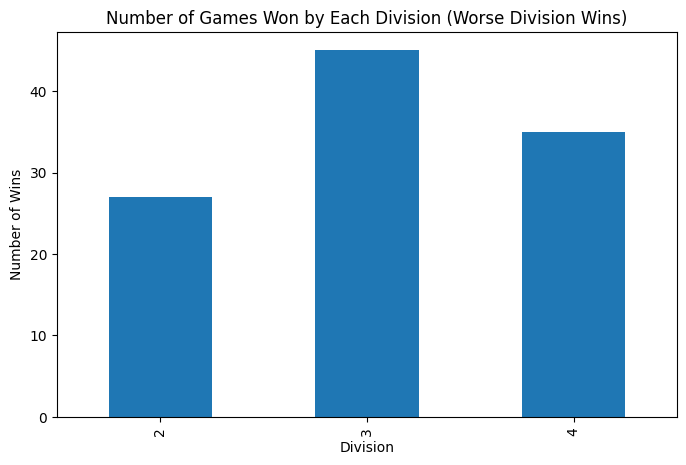

In [5]:
# Count the number of wins for each division in selected_df
home_wins = selected_df[selected_df['home_score'] > selected_df['away_score']]['home_division'].value_counts()
away_wins = selected_df[selected_df['away_score'] > selected_df['home_score']]['away_division'].value_counts()

# Combine home and away wins
division_wins = home_wins.add(away_wins, fill_value=0).sort_index()

# Plot the results
plt.figure(figsize=(8, 5))
division_wins.plot(kind='bar')
plt.xlabel('Division')
plt.ylabel('Number of Wins')
plt.title('Number of Games Won by Each Division (Worse Division Wins)')
plt.show()

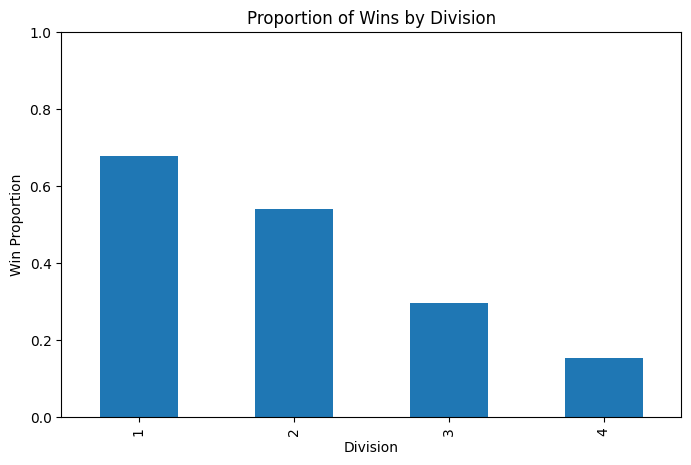

In [6]:
# Count total games played by teams from each division (as home or away)
home_games = df['home_division'].value_counts().sort_index()
away_games = df['away_division'].value_counts().sort_index()
total_games = home_games.add(away_games, fill_value=0)

# Count total wins by teams from each division (home or away)
home_win_mask = df['home_score'] > df['away_score']
away_win_mask = df['away_score'] > df['home_score']
home_wins = df.loc[home_win_mask, 'home_division'].value_counts().sort_index()
away_wins = df.loc[away_win_mask, 'away_division'].value_counts().sort_index()
total_wins = home_wins.add(away_wins, fill_value=0)

# Calculate win proportion for each division
win_proportion = (total_wins / total_games).sort_index()

# Visualize
plt.figure(figsize=(8, 5))
win_proportion.plot(kind='bar')
plt.xlabel('Division')
plt.ylabel('Win Proportion')
plt.title('Proportion of Wins by Division')
plt.ylim(0, 1)
plt.show()

C:\Users\Armin\AppData\Local\Temp\ipykernel_12048\2127336757.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lower_division_wins_vs_bundesliga['lower_division'] = lower_division_wins_vs_bundesliga.apply(get_lower_div, axis=1)
C:\Users\Armin\AppData\Local\Temp\ipykernel_12048\2127336757.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games_vs_bundesliga['lower_division'] = games_vs_bundesliga.apply(get_lower_div_game, axis=1)


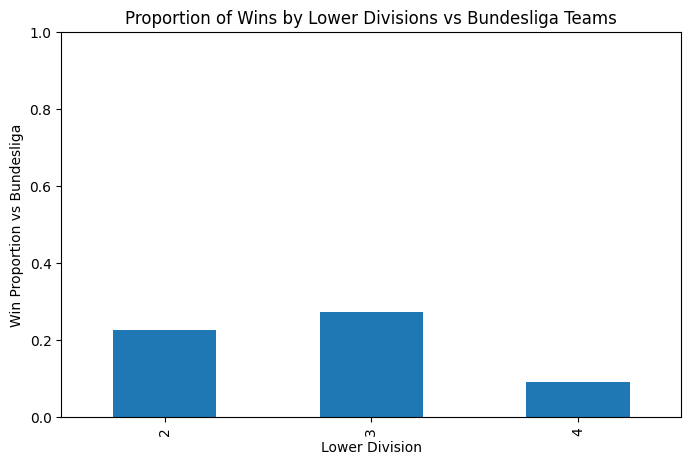

In [10]:
# Calculate the proportion of games teams from lower divisions won against Bundesliga teams

# Filter games where one team is Bundesliga (division 1) and the other is a lower division (2, 3, 4)
games_vs_bundesliga = df[
    ((df['home_division'].astype(int) == 1) & (df['away_division'].astype(int) > 1)) |
    ((df['away_division'].astype(int) == 1) & (df['home_division'].astype(int) > 1))
]

# Find wins by lower division teams in these games
lower_division_win_mask = (
    ((games_vs_bundesliga['home_division'].astype(int) > games_vs_bundesliga['away_division'].astype(int)) & (games_vs_bundesliga['home_score'] > games_vs_bundesliga['away_score'])) |
    ((games_vs_bundesliga['away_division'].astype(int) > games_vs_bundesliga['home_division'].astype(int)) & (games_vs_bundesliga['away_score'] > games_vs_bundesliga['home_score']))
)

lower_division_wins_vs_bundesliga = games_vs_bundesliga[lower_division_win_mask]

# Count wins by lower division (grouped by lower division)
def get_lower_div(row):
    if row['home_score'] > row['away_score']:
        return int(row['home_division'])
    else:
        return int(row['away_division'])

lower_division_wins_vs_bundesliga['lower_division'] = lower_division_wins_vs_bundesliga.apply(get_lower_div, axis=1)
lower_division_win_counts = lower_division_wins_vs_bundesliga['lower_division'].value_counts().sort_index()

# Count total games played by each lower division vs Bundesliga
def get_lower_div_game(row):
    if int(row['home_division']) > int(row['away_division']):
        return int(row['home_division'])
    else:
        return int(row['away_division'])

games_vs_bundesliga['lower_division'] = games_vs_bundesliga.apply(get_lower_div_game, axis=1)
lower_division_game_counts = games_vs_bundesliga['lower_division'].value_counts().sort_index()

# Calculate win proportion
lower_division_win_prop_vs_bundesliga = (lower_division_win_counts / lower_division_game_counts).sort_index()

# Visualize the proportion
lower_division_win_prop_vs_bundesliga.plot(kind='bar', figsize=(8, 5))
plt.xlabel('Lower Division')
plt.ylabel('Win Proportion vs Bundesliga')
plt.title('Proportion of Wins by Lower Divisions vs Bundesliga Teams')
plt.ylim(0, 1)
plt.show()

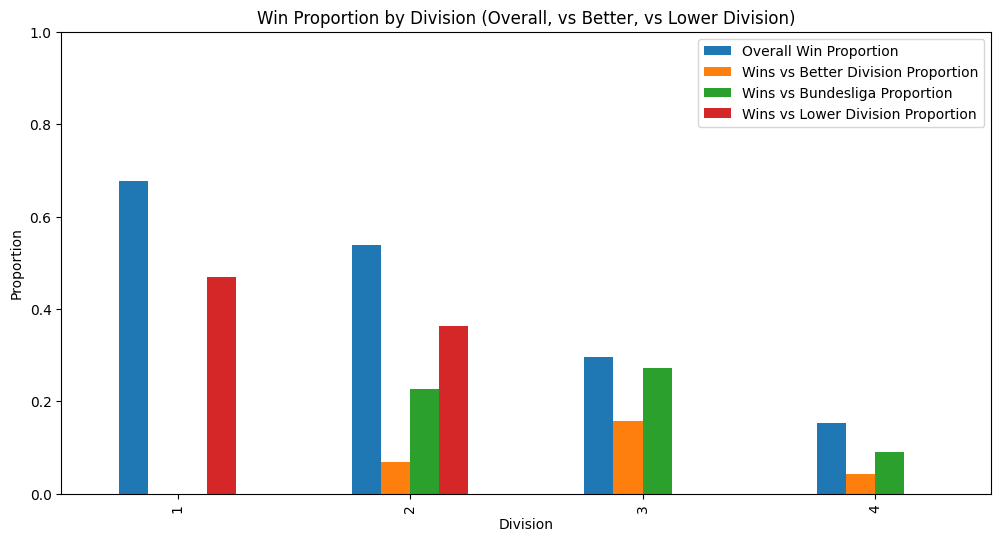

In [9]:
# Calculate wins against lower division (higher number)
# For home teams: home_division < away_division and home wins
home_better_win_mask = (df['home_division'].astype(int) < df['away_division'].astype(int)) & (df['home_score'] > df['away_score'])
# For away teams: away_division < home_division and away wins
away_better_win_mask = (df['away_division'].astype(int) < df['home_division'].astype(int)) & (df['away_score'] > df['home_score'])

# Count wins against lower division for each division
home_better_wins = df.loc[home_better_win_mask, 'home_division'].value_counts().sort_index()
away_better_wins = df.loc[away_better_win_mask, 'away_division'].value_counts().sort_index()
better_division_wins = home_better_wins.add(away_better_wins, fill_value=0)

# Proportion of wins against lower division
better_win_proportion = (better_division_wins / total_games).sort_index()

# Add to plot_df
plot_df['Wins vs Lower Division Proportion'] = better_win_proportion

# Plot all three proportions
plot_df.plot(kind='bar', figsize=(12, 6))
plt.xlabel('Division')
plt.ylabel('Proportion')
plt.title('Win Proportion by Division (Overall, vs Better, vs Lower Division)')
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.show()

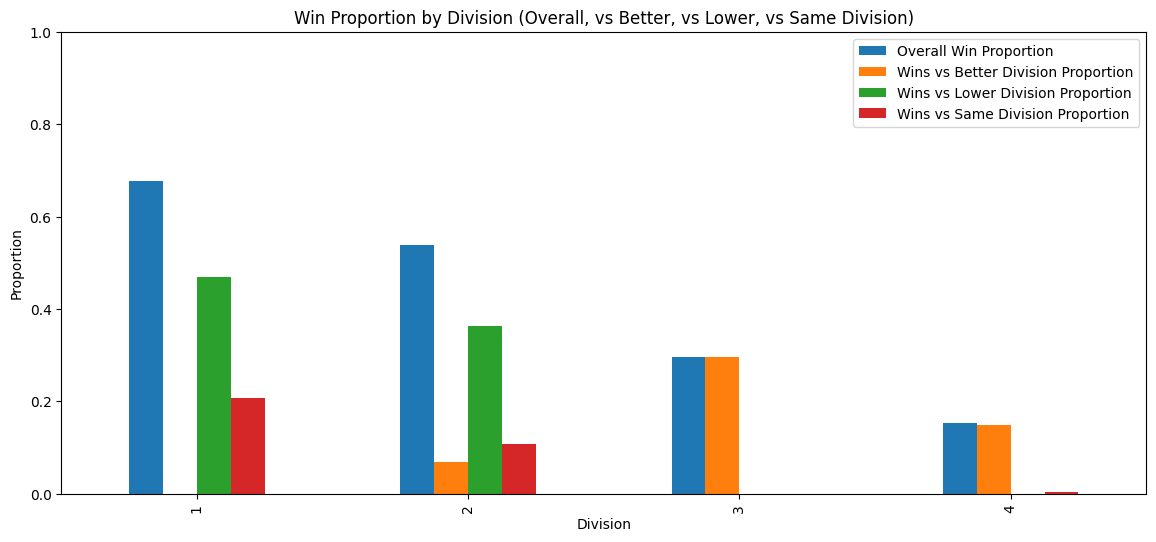

In [17]:
# Calculate wins against same division (home_division == away_division and winner)
same_division_mask = (df['home_division'].astype(int) == df['away_division'].astype(int))
home_same_division_win = df.loc[same_division_mask & (df['home_score'] > df['away_score']), 'home_division'].value_counts().sort_index()
away_same_division_win = df.loc[same_division_mask & (df['away_score'] > df['home_score']), 'away_division'].value_counts().sort_index()
same_division_wins = home_same_division_win.add(away_same_division_win, fill_value=0)

# Proportion of wins against same division
same_division_win_proportion = (same_division_wins / total_games).sort_index()

# Add to plot_df
plot_df['Wins vs Same Division Proportion'] = same_division_win_proportion

# Plot all four proportions
plot_df.plot(kind='bar', figsize=(14, 6))
plt.xlabel('Division')
plt.ylabel('Proportion')
plt.title('Win Proportion by Division (Overall, vs Better, vs Lower, vs Same Division)')
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.show()